# 01. Imports

In [ ]:
import os
from typing import Optional, List

import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from scipy.stats import spearmanr

# 02. Config

In [ ]:
CONFIG = {
    "csv_path": "data/processed/final_training_dataset.csv",
    "base_dir": "data",
    "model_path": "data/saved_models/best_models/best_model.pth",
    "batch_size": 32,
    "img_size": 224,
    "num_workers": 2,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

CONCEPT_NAMES = ["NO", "NC", "CO", "PSC"]

# 03. Helpers

In [ ]:
def find_first_existing_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def safe_float(value, default=np.nan):
    try:
        if pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default


def score_0_5_to_0_1(x: float) -> float:
    x = safe_float(x, default=np.nan)
    if np.isnan(x):
        return np.nan
    return np.clip(x / 5.0, 0.0, 1.0)


def infer_presence_from_concepts(concept_values_0_1: np.ndarray) -> float:
    """
    Same weak rule used in training:
    if any valid concept >= 0.20 (equivalent to 1.0/5.0), mark presence as 1.
    """
    if np.all(np.isnan(concept_values_0_1)):
        return 0.0

    valid = concept_values_0_1[~np.isnan(concept_values_0_1)]
    if len(valid) == 0:
        return 0.0

    return 1.0 if np.max(valid) >= 0.20 else 0.0


def get_severity_label(score_0_to_5: float) -> str:
    if score_0_to_5 < 1.0:
        return "Normal"
    elif score_0_to_5 < 2.0:
        return "Mild"
    elif score_0_to_5 < 3.5:
        return "Moderate"
    else:
        return "Severe"


def to_severity_vector(values_0_to_5: np.ndarray):
    return [get_severity_label(float(v)) for v in values_0_to_5]


def compute_overall_severity_score(concepts_0_to_5: np.ndarray) -> float:
    weights = np.array([0.35, 0.35, 0.15, 0.15], dtype=float)
    weighted_score = float(np.sum(concepts_0_to_5 * weights))
    max_score = float(np.max(concepts_0_to_5))
    final_score = 0.6 * max_score + 0.4 * weighted_score
    return final_score


def get_overall_severity_label(concepts_0_to_5: np.ndarray) -> str:
    return get_severity_label(compute_overall_severity_score(concepts_0_to_5))

# 04. Model

In [ ]:
class CBMModel(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.shared = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.concept_head = nn.Linear(128, 4)
        self.presence_head = nn.Linear(128, 1)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        shared = self.shared(x)

        concepts = torch.sigmoid(self.concept_head(shared))
        presence = self.presence_head(shared)

        return concepts, presence

# 05. Dataset

In [ ]:
class CataractDataset(Dataset):
    def __init__(self, df, transform=None, base_dir=""):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.base_dir = base_dir

        self.path_col = find_first_existing_column(
            self.df, ["relative_path", "image_path", "path"]
        )
        if self.path_col is None:
            raise ValueError("No valid image path column found. Expected one of: relative_path, image_path, path")

        self.concept_cols = {
            "NO": find_first_existing_column(self.df, ["NO", "NO_pseudo"]),
            "NC": find_first_existing_column(self.df, ["NC", "NC_pseudo"]),
            "CO": find_first_existing_column(self.df, ["CO", "CO_pseudo", "C", "C_pseudo"]),
            "PSC": find_first_existing_column(self.df, ["PSC", "PSC_pseudo", "P", "P_pseudo"]),
        }

        missing = [k for k, v in self.concept_cols.items() if v is None]
        if missing:
            raise ValueError(f"Missing required concept columns for: {missing}")

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, raw_path: str) -> str:
        raw_path = str(raw_path).replace("\\", "/")
        if os.path.isabs(raw_path):
            return raw_path
        return os.path.join(self.base_dir, raw_path)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = self._resolve_image_path(row[self.path_col])
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image file not found at: {img_path}")

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        concept_values_0_5 = []
        concept_mask = []

        for concept_name in CONCEPT_NAMES:
            col = self.concept_cols[concept_name]
            raw_val = safe_float(row[col], default=np.nan)

            if np.isnan(raw_val):
                concept_values_0_5.append(0.0)
                concept_mask.append(0.0)
            else:
                concept_values_0_5.append(np.clip(raw_val, 0.0, 5.0))
                concept_mask.append(1.0)

        concept_values_0_5 = np.array(concept_values_0_5, dtype=np.float32)
        concept_values_0_1 = np.array([score_0_5_to_0_1(v) for v in concept_values_0_5], dtype=np.float32)
        concept_mask = np.array(concept_mask, dtype=np.float32)
        presence_target = infer_presence_from_concepts(concept_values_0_1)

        return image, {
            "concepts_0_5": torch.tensor(concept_values_0_5, dtype=torch.float32),
            "concepts_0_1": torch.tensor(concept_values_0_1, dtype=torch.float32),
            "concept_mask": torch.tensor(concept_mask, dtype=torch.float32),
            "presence": torch.tensor([presence_target], dtype=torch.float32),
        }

# 06. Transform

In [ ]:
transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# 07. Main Function

Loading dataset...
Loading model...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


Running evaluation...

===== Presence Prediction Metrics =====
Accuracy : 0.8209
Precision: 0.9878
Recall   : 0.7507
F1-score : 0.8531
Confusion Matrix:
[[1220   26]
 [ 700 2108]]

===== Concept Regression Metrics =====
NO: MAE=0.3732, MSE=0.4234, Spearman=0.7479
NC: MAE=0.3680, MSE=0.4187, Spearman=0.7470
CO: MAE=0.3721, MSE=0.4356, Spearman=0.7474
PSC: MAE=0.3777, MSE=0.5638, Spearman=0.6084


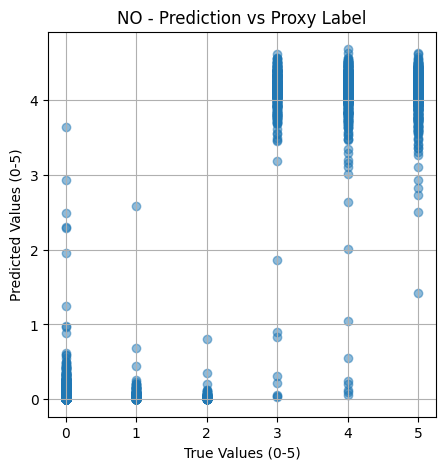

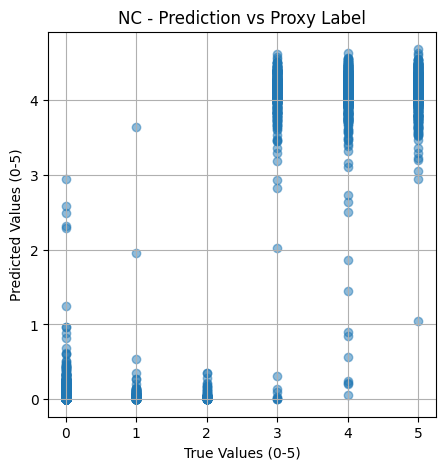

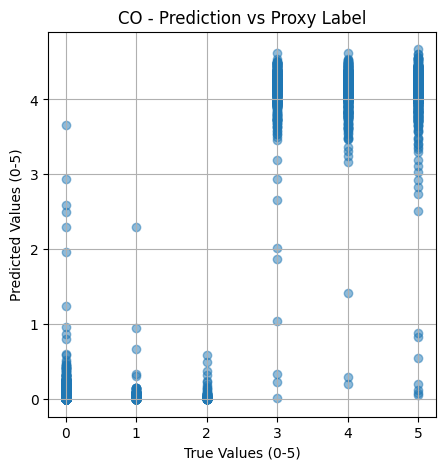

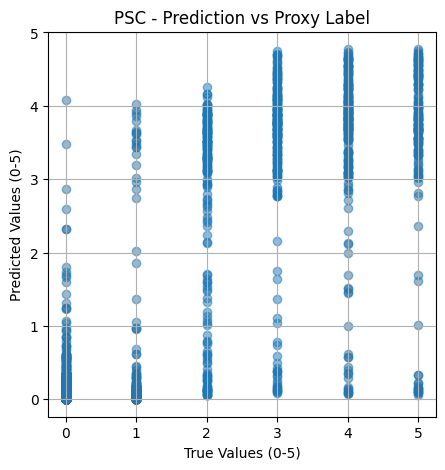

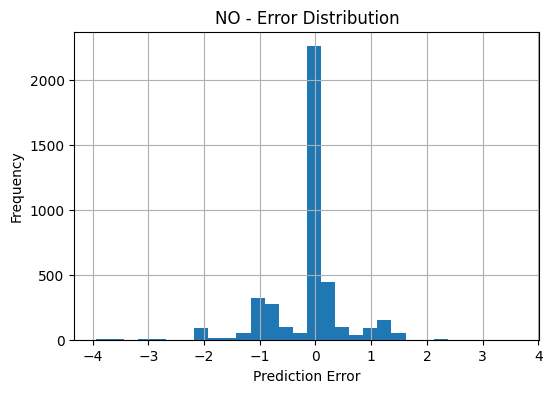

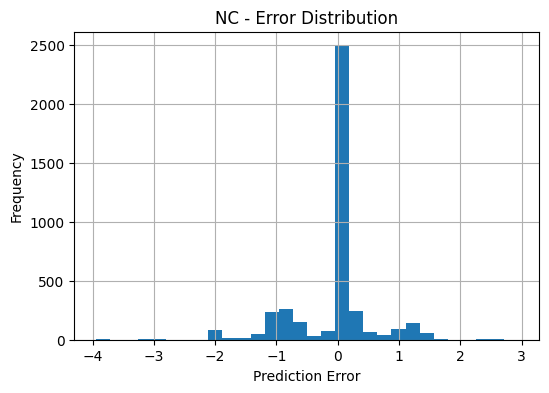

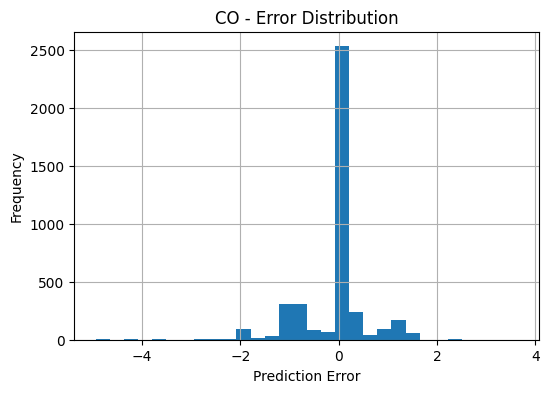

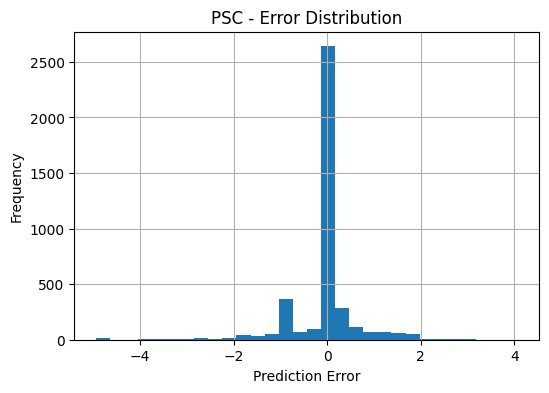


===== Worst Predictions =====

Sample 3052
True: [4. 4. 5. 0.]
Pred: [0.05 0.05 0.05 0.07]
Mask: [1 1 1 1]
Error: [-3.95 -3.95 -4.95  0.07]
Presence True / Pred Prob: 1 0.3372

Sample 2077
True: [4. 3. 5. 0.]
Pred: [0.09 0.09 0.09 0.11]
Mask: [1 1 1 1]
Error: [-3.91 -2.91 -4.91  0.11]
Presence True / Pred Prob: 1 0.3474

Sample 1473
True: [4. 3. 5. 0.]
Pred: [0.13 0.13 0.13 0.18]
Mask: [1 1 1 1]
Error: [-3.87 -2.87 -4.87  0.18]
Presence True / Pred Prob: 1 0.3712

Sample 2686
True: [3. 4. 5. 0.]
Pred: [0.21 0.22 0.21 0.25]
Mask: [1 1 1 1]
Error: [-2.79 -3.78 -4.79  0.25]
Presence True / Pred Prob: 1 0.3854

Sample 479
True: [4. 4. 5. 0.]
Pred: [0.56 0.56 0.55 0.21]
Mask: [1 1 1 1]
Error: [-3.44 -3.44 -4.45  0.21]
Presence True / Pred Prob: 1 0.4859

===== Per-Concept Severity Classification =====

===== Nuclear Opalescence (NO) =====
              precision    recall  f1-score   support

        Mild       0.00      0.00      0.00       217
    Moderate       0.12      0.01      0.02 

In [ ]:
def main():
    print("Loading dataset...")
    df = pd.read_csv(CONFIG["csv_path"])

    concept_candidates = {
        "NO": find_first_existing_column(df, ["NO", "NO_pseudo"]),
        "NC": find_first_existing_column(df, ["NC", "NC_pseudo"]),
        "CO": find_first_existing_column(df, ["CO", "CO_pseudo", "C", "C_pseudo"]),
        "PSC": find_first_existing_column(df, ["PSC", "PSC_pseudo", "P", "P_pseudo"]),
    }

    def row_presence_target(row):
        vals = []
        for k in CONCEPT_NAMES:
            v = score_0_5_to_0_1(row[concept_candidates[k]])
            vals.append(v)
        vals = np.array(vals, dtype=np.float32)
        return infer_presence_from_concepts(vals)

    df["_presence_target"] = df.apply(row_presence_target, axis=1)

    try:
        _, val_df = train_test_split(
            df,
            test_size=0.2,
            random_state=42,
            stratify=df["_presence_target"],
        )
    except Exception:
        _, val_df = train_test_split(
            df,
            test_size=0.2,
            random_state=42,
        )

    val_ds = CataractDataset(val_df, transform=transform, base_dir=CONFIG["base_dir"])
    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=torch.cuda.is_available(),
    )

    print("Loading model...")
    model = CBMModel().to(CONFIG["device"])
    checkpoint = torch.load(CONFIG["model_path"], map_location=CONFIG["device"], weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    all_pred_concepts_0_5 = []
    all_true_concepts_0_5 = []
    all_masks = []

    all_pred_presence_prob = []
    all_true_presence = []

    print("Running evaluation...")

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(CONFIG["device"])

            true_concepts_0_5 = labels["concepts_0_5"].numpy()
            true_presence = labels["presence"].numpy()

            pred_concepts_0_1, pred_presence_logits = model(images)
            pred_concepts_0_5 = (pred_concepts_0_1.cpu().numpy() * 5.0).clip(0.0, 5.0)
            pred_presence_prob = torch.sigmoid(pred_presence_logits).cpu().numpy()

            all_pred_concepts_0_5.append(pred_concepts_0_5)
            all_true_concepts_0_5.append(true_concepts_0_5)
            all_masks.append(labels["concept_mask"].numpy())

            all_pred_presence_prob.append(pred_presence_prob)
            all_true_presence.append(true_presence)

    all_pred_concepts_0_5 = np.concatenate(all_pred_concepts_0_5, axis=0)
    all_true_concepts_0_5 = np.concatenate(all_true_concepts_0_5, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)

    all_pred_presence_prob = np.concatenate(all_pred_presence_prob, axis=0).reshape(-1)
    all_true_presence = np.concatenate(all_true_presence, axis=0).reshape(-1)

    # 1. PRESENCE METRICS

    print("\n===== Presence Prediction Metrics =====")
    pred_presence_bin = (all_pred_presence_prob >= 0.5).astype(int)
    true_presence_bin = all_true_presence.astype(int)

    presence_acc = accuracy_score(true_presence_bin, pred_presence_bin)
    presence_precision = precision_score(true_presence_bin, pred_presence_bin, zero_division=0)
    presence_recall = recall_score(true_presence_bin, pred_presence_bin, zero_division=0)
    presence_f1 = f1_score(true_presence_bin, pred_presence_bin, zero_division=0)

    print(f"Accuracy : {presence_acc:.4f}")
    print(f"Precision: {presence_precision:.4f}")
    print(f"Recall   : {presence_recall:.4f}")
    print(f"F1-score : {presence_f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(true_presence_bin, pred_presence_bin))

    # 2. CONCEPT REGRESSION METRICS

    print("\n===== Concept Regression Metrics =====")

    for i, name in enumerate(CONCEPT_NAMES):
        valid = all_masks[:, i] > 0.5

        if valid.sum() == 0:
            print(f"{name}: No valid labels found.")
            continue

        y_true = all_true_concepts_0_5[valid, i]
        y_pred = all_pred_concepts_0_5[valid, i]

        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)

        corr, _ = spearmanr(y_true, y_pred)
        if np.isnan(corr):
            corr = 0.0

        print(f"{name}: MAE={mae:.4f}, MSE={mse:.4f}, Spearman={corr:.4f}")

    # 3. SCATTER PLOTS

    for i, name in enumerate(CONCEPT_NAMES):
        valid = all_masks[:, i] > 0.5
        if valid.sum() == 0:
            continue

        plt.figure(figsize=(5, 5))
        plt.scatter(all_true_concepts_0_5[valid, i], all_pred_concepts_0_5[valid, i], alpha=0.5)
        plt.xlabel("True Values (0-5)")
        plt.ylabel("Predicted Values (0-5)")
        plt.title(f"{name} - Prediction vs Proxy Label")
        plt.grid(True)
        plt.show()

    # 4. ERROR DISTRIBUTION

    errors = all_pred_concepts_0_5 - all_true_concepts_0_5

    for i, name in enumerate(CONCEPT_NAMES):
        valid = all_masks[:, i] > 0.5
        if valid.sum() == 0:
            continue

        plt.figure(figsize=(6, 4))
        plt.hist(errors[valid, i], bins=30)
        plt.title(f"{name} - Error Distribution")
        plt.xlabel("Prediction Error")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

    # 5. WORST PREDICTIONS

    valid_counts = np.clip(all_masks.sum(axis=1), 1.0, None)
    total_error = (np.abs(errors) * all_masks).sum(axis=1) / valid_counts
    worst_indices = np.argsort(-total_error)[:5]

    print("\n===== Worst Predictions =====")
    for idx in worst_indices:
        print(f"\nSample {idx}")
        print("True:", np.round(all_true_concepts_0_5[idx], 2))
        print("Pred:", np.round(all_pred_concepts_0_5[idx], 2))
        print("Mask:", all_masks[idx].astype(int))
        print("Error:", np.round(errors[idx], 2))
        print("Presence True / Pred Prob:",
              int(all_true_presence[idx]),
              round(float(all_pred_presence_prob[idx]), 4))

    # 6. PER-CONCEPT SEVERITY AGREEMENT

    print("\n===== Per-Concept Severity Classification =====")

    concept_labels_pretty = [
        "Nuclear Opalescence (NO)",
        "Nuclear Color (NC)",
        "Cortical Opacity (CO)",
        "Posterior Subcapsular (PSC)",
    ]

    for i, pretty_name in enumerate(concept_labels_pretty):
        valid = all_masks[:, i] > 0.5
        if valid.sum() == 0:
            print(f"\n===== {pretty_name} =====")
            print("No valid labels found.")
            continue

        pred_severity = np.array([get_severity_label(v) for v in all_pred_concepts_0_5[valid, i]])
        true_severity = np.array([get_severity_label(v) for v in all_true_concepts_0_5[valid, i]])

        print(f"\n===== {pretty_name} =====")
        print(classification_report(true_severity, pred_severity, zero_division=0))
        print("Confusion Matrix:")
        print(confusion_matrix(true_severity, pred_severity))

    # 7. OVERALL SEVERITY AGREEMENT

    print("\n===== Overall Severity Agreement =====")

    true_overall = np.array([get_overall_severity_label(x) for x in all_true_concepts_0_5])
    pred_overall = np.array([get_overall_severity_label(x) for x in all_pred_concepts_0_5])

    print(classification_report(true_overall, pred_overall, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(true_overall, pred_overall))


if __name__ == "__main__":
    main()